Import des librairies et Chargement des données

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("../PRE/merged_cleaned.csv")

H1 : Consommation vs niveau d’instruction des parents

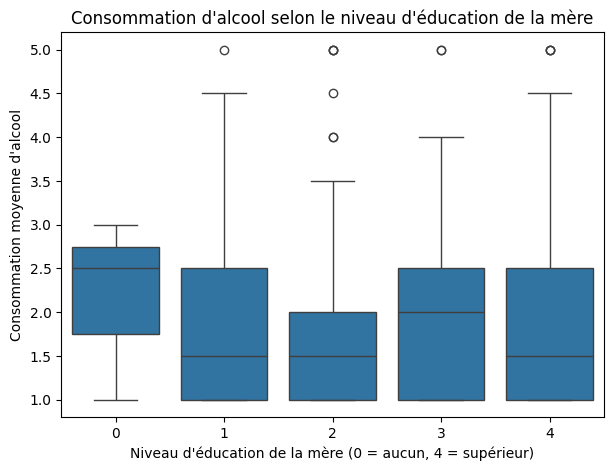

      count      mean       std  min   25%  50%   75%  max
Medu                                                      
0       3.0  2.166667  1.040833  1.0  1.75  2.5  2.75  3.0
1      51.0  1.921569  0.981695  1.0  1.00  1.5  2.50  5.0
2      98.0  1.734694  0.971777  1.0  1.00  1.5  2.00  5.0
3      95.0  2.015789  1.024832  1.0  1.00  2.0  2.50  5.0
4     135.0  1.859259  0.972863  1.0  1.00  1.5  2.50  5.0


In [3]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Medu", y="alcohol_avg", data=df)
plt.title("Consommation d'alcool selon le niveau d'éducation de la mère")
plt.xlabel("Niveau d'éducation de la mère (0 = aucun, 4 = supérieur)")
plt.ylabel("Consommation moyenne d'alcool")
plt.savefig("./figures/alcohol_vs_medu.png")
plt.show()
print(df.groupby("Medu")["alcohol_avg"].describe())

Père :

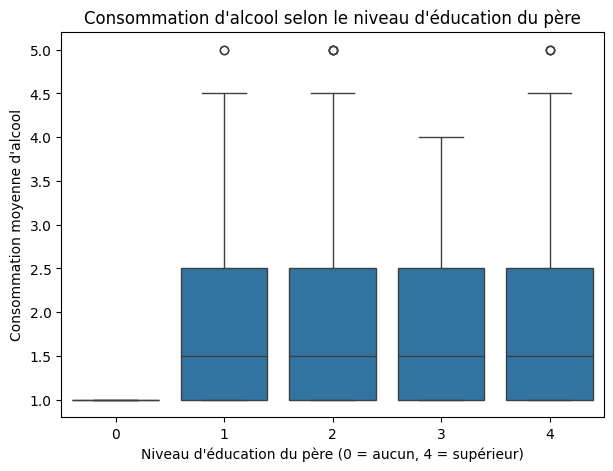

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Fedu", y="alcohol_avg", data=df)
plt.title("Consommation d'alcool selon le niveau d'éducation du père")
plt.xlabel("Niveau d'éducation du père (0 = aucun, 4 = supérieur)")
plt.ylabel("Consommation moyenne d'alcool")
plt.savefig("./figures/alcohol_vs_fedu.png")
plt.show()
print(df.groupby("Fedu")["alcohol_avg"].describe())

H2 : Taux de réussite selon abus d'alcool

C:\Users\geams\AppData\Local\Temp\ipykernel_20196\2946680736.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="abuse_alcohol", y="success", data=df, ci=None)


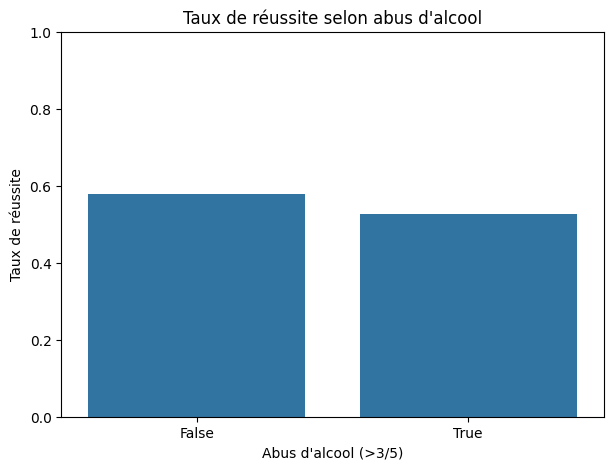

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(x="abuse_alcohol", y="success", data=df, ci=None)
plt.title("Taux de réussite selon abus d'alcool")
plt.xlabel("Abus d'alcool (>3/5)")
plt.ylabel("Taux de réussite")
plt.ylim(0, 1)


# Enregistrer la figure
plt.savefig("./figures/success_vs_abuse.png")
plt.show()

print(df.groupby("abuse_alcohol")["success"].describe())
print(df["abuse_alcohol"].value_counts(normalize=True))

H3 :Consommation d'alcool selon le sexe

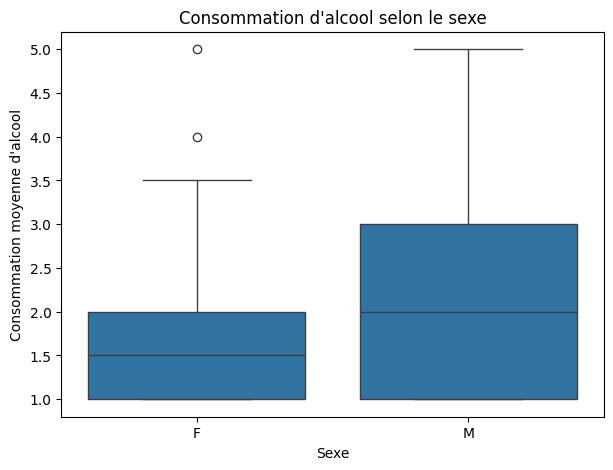

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x="sex", y="alcohol_avg", data=df)
plt.title("Consommation d'alcool selon le sexe")
plt.xlabel("Sexe")
plt.ylabel("Consommation moyenne d'alcool")

plt.savefig("./figures/alcohol_by_sex.png")
plt.show()
print(df.groupby("sex")["alcohol_avg"].describe())

Proportion garçons/filles abusant d’alcool

C:\Users\geams\AppData\Local\Temp\ipykernel_20196\371275789.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="sex", y="abuse_alcohol", data=df, ci=None)


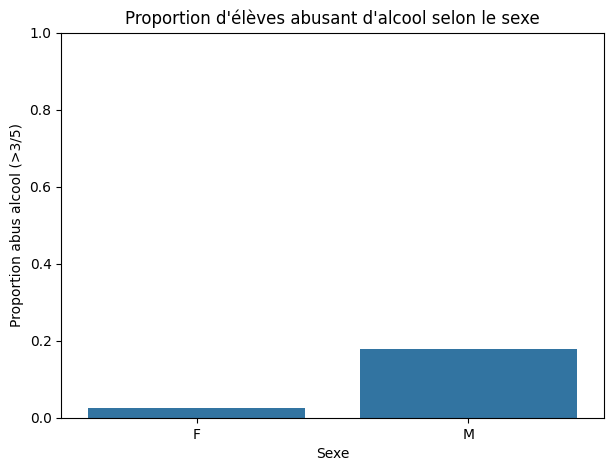

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(x="sex", y="abuse_alcohol", data=df, ci=None)
plt.title("Proportion d'élèves abusant d'alcool selon le sexe")
plt.xlabel("Sexe")
plt.ylabel("Proportion abus alcool (>3/5)")
plt.ylim(0, 1)
plt.savefig("./figures/abuse_by_sex.png")
plt.show()
print(df.groupby("sex")["abuse_alcohol"].mean())

H4 : Consommation semaine vs week-end

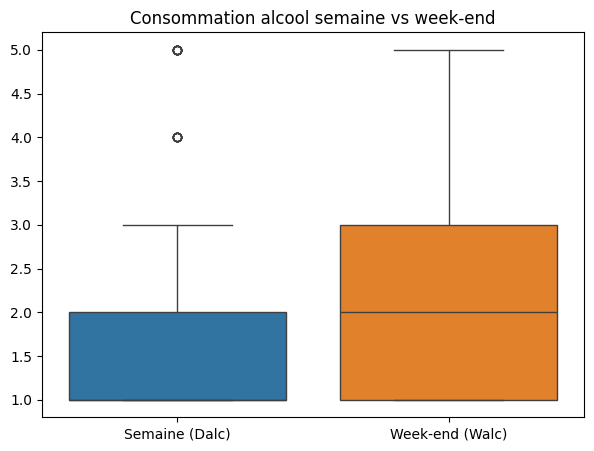

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df[['Dalc_math', 'Walc_math']])
plt.title("Consommation alcool semaine vs week-end")
plt.xticks([0,1], ['Semaine (Dalc)', 'Week-end (Walc)'])

plt.savefig("./figures/weekend_vs_week.png")
plt.show()

print("Consommation moyenne en semaine (Dalc) :", df["Dalc_math"].mean())
print("Consommation moyenne le week-end (Walc) :", df["Walc_math"].mean())

H5 : Consommation selon lieu de résidence

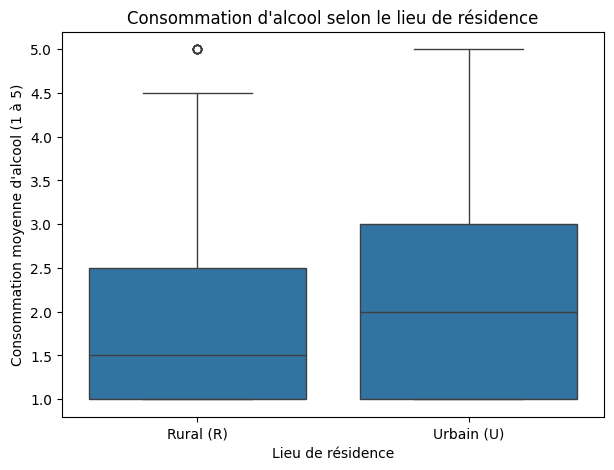

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x="address", y="alcohol_avg", data=df)
plt.xticks([0, 1], ["Rural (R)", "Urbain (U)"])
plt.title("Consommation d'alcool selon le lieu de résidence")
plt.xlabel("Lieu de résidence")
plt.ylabel("Consommation moyenne d'alcool (1 à 5)")

plt.savefig("./figures/alcohol_by_address.png")
plt.show()

print(df.groupby("address")["alcohol_avg"].describe())

H6 : Consommation d’alcool vs absences

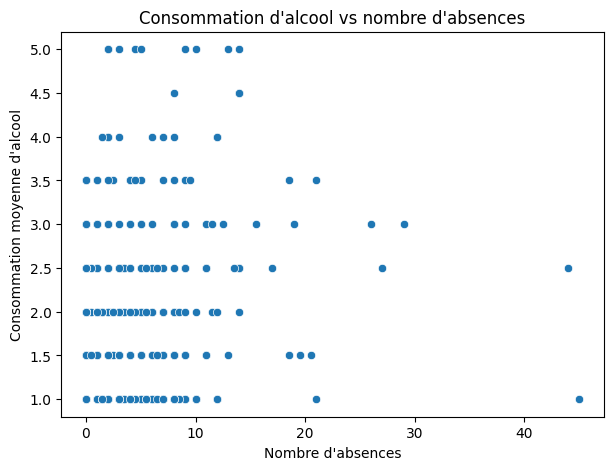

In [ ]:
# Créer la colonne 'absences' comme moyenne de 'absences_math' et 'absences_por'
df["absences"] = df[["absences_math", "absences_por"]].mean(axis=1)

plt.figure(figsize=(7,5))
sns.scatterplot(x="absences", y="alcohol_avg", data=df)
plt.title("Consommation d'alcool vs nombre d'absences")
plt.xlabel("Nombre d'absences")
plt.ylabel("Consommation moyenne d'alcool")
plt.savefig("./figures/alcohol_vs_absences.png")
plt.show()
print(df[["absences", "alcohol_avg"]].corr())

Boxplot groupé par tranches d’absences

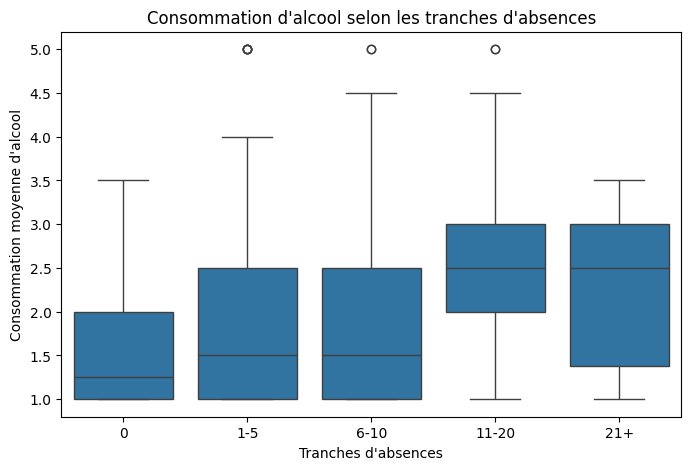

In [ ]:
# Créer des catégories d'absences
df["absences_cat"] = pd.cut(df["absences"], bins=[-1, 0, 5, 10, 20, 100], 
                            labels=["0", "1-5", "6-10", "11-20", "21+"])

plt.figure(figsize=(8,5))
sns.boxplot(x="absences_cat", y="alcohol_avg", data=df)
plt.title("Consommation d'alcool selon les tranches d'absences")
plt.xlabel("Tranches d'absences")
plt.ylabel("Consommation moyenne d'alcool")
plt.savefig("./figures/boxplot_alcohol_by_absences_cat.png")
plt.show()

print(df.groupby("absences_cat")["alcohol_avg"].describe())


Régression linéaire simple (lmplot)

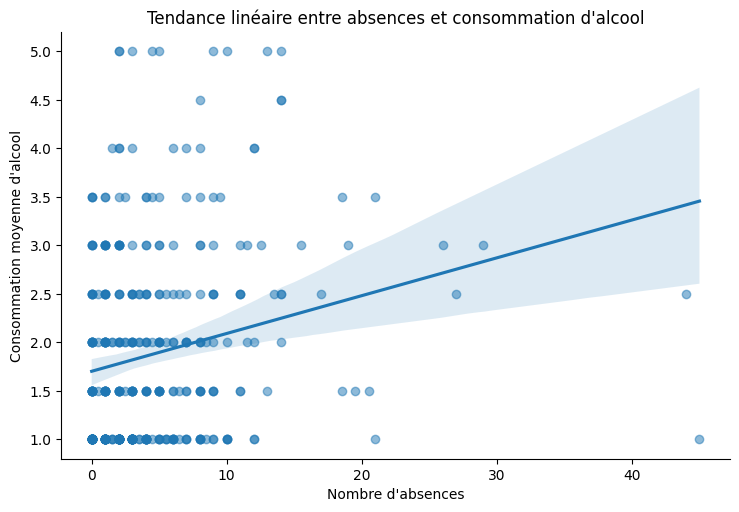

In [12]:
sns.lmplot(x="absences", y="alcohol_avg", data=df, aspect=1.5, scatter_kws={'alpha':0.5})
plt.title("Tendance linéaire entre absences et consommation d'alcool")
plt.xlabel("Nombre d'absences")
plt.ylabel("Consommation moyenne d'alcool")
plt.savefig("./figures/lmplot_alcohol_vs_absences.png")
plt.show()